# General Building Datasets Validity Testing and Development of Positive Calibration Test
**Author:** Eliya Levin

**Contact details:** please mail questions to eliya.levin@mail.huji.ac.il

**Last update:** 17/05/2026

## Setup

### Libraries

In [2]:
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import time
from IPython.display import Markdown
from shapely import wkb
import glob
import sys
import importlib

### Path

In [3]:
current_dir = os.getcwd() # directory path of the notebook
main_dir = os.path.abspath(os.path.join(current_dir, "..")) # parent directory path of the notebook

In [4]:
data_path = r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\Data'

### Link function notebook

In [5]:
# Adding path to system
sys.path.append(main_dir)

In [6]:
# Importing relevant functions
from functions import get_len, get_count, post_count, get_area, post_area, get_density, wrap_api_query # API call requests
from functions import get_add_from_cum, semi_norm_mix_transform, assess_feature_completeness # Method functions
from functions import generate_measure_sample_plot # plotting functions

## Data upload

### European Union Datasets

Found in their [Data Pool](https://data.europa.eu/data/combined?locale=en&query=building&page=2&limit=10)

#### Italian building dataset
[Data link](https://data.europa.eu/data/datasets/c_c415-edificio-1?locale=en)

In [7]:
italian_bld = gpd.read_file(data_path + r'\italian_building_data.geojson')

<Axes: >

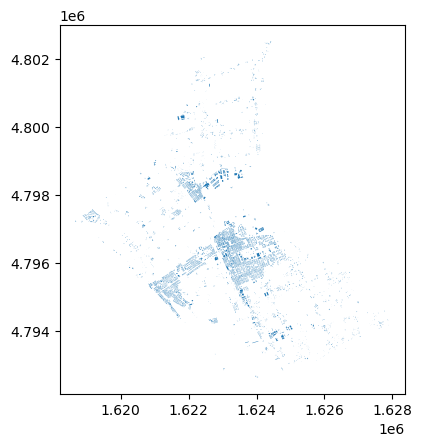

In [8]:
italian_bld.plot()

#### Dutch Road Dataset

[Data link](https://docs.ndw.nu/handleidingen/nwb/?utm_source=chatgpt.com)

In [9]:
dutch_rd = gpd.read_file(r'C:\GIS\1_Work\OSM_research\sandbox\dutch data\Wegvakken.shp')

<Axes: >

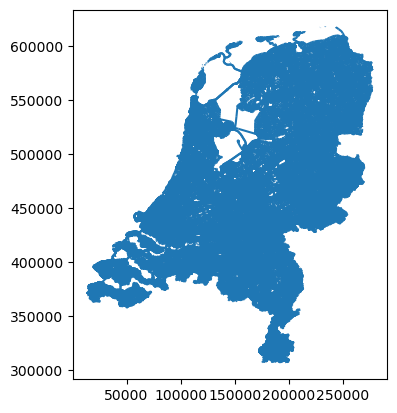

In [10]:
dutch_rd.plot()

#### Netherland official building data

[data link](https://www.kadaster.nl/-/gratis-download-bag-extract) (3 GB of data, need to download to Cluster)

#### Switzerland official building data

[data link](https://www.swisstopo.admin.ch/en/landscape-model-swissbuildings3d-2-0#swissBUILDINGS3D-2.0---Download) (3.4 GB of data, need to download to Cluster)

#### France official building data

[data link](https://cadastre.data.gouv.fr/datasets) (Still haven't figured how to download)

#### Spain official building data

[data link](https://datos.gob.es/en/catalogo/e0dat0002-buildings-of-dg-cadastre-spain) (Still haven't figured how to download)

### EUBUCU Data

[Data link](https://eubucco.com/files/v0.2)

In [ ]:
# EUBUCU arguments for extraction
storage_opts = {
    "anon": True,
    "client_kwargs": {"endpoint_url": "https://s3.eubucco.com"}
}

# Data extraction using EUBUCU API
path = "s3://eubucco/v0.2/buildings/parquet/nuts_id=FRB0/FRB0.parquet"
vale_de_loire = gpd.read_parquet(path, storage_options=storage_opts)

<Axes: >

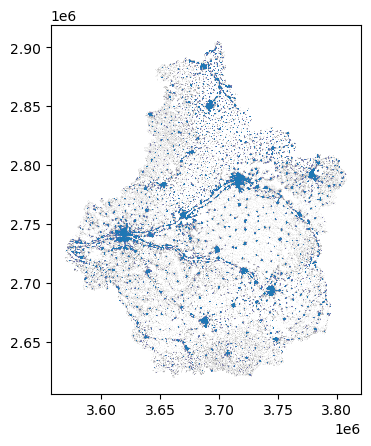

In [21]:
vale_de_loire.plot()

In [23]:
avg_bld_loire = np.mean(vale_de_loire.area)
print(f'Valle de Loire average building area: {avg_bld_loire}')

Valle de Loire average building area: 115.66103487577811


### Google open building Dataset
Created using satellite imagery, found in this [link](https://sites.research.google/gr/open-buildings/)
